In [13]:
import json
from pathlib import Path

import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [14]:
RAW_PATH = Path("../data/raw/iowa_crash_data_raw.json")

with RAW_PATH.open("r", encoding="utf-8") as file:
    raw_data = json.load(file)

crashes = pd.DataFrame(
    feature["attributes"]
    for feature in raw_data["features"]
)

In [15]:
crashes.head()

,OBJECTID,CRASH_KEY,CRASH_DATE,CRASH_DATETIME,COUNTY_NUMBER,COUNTY_NAME,CSEV,WEATHER,CSRFCND
0,8931903,2.015841e+09,1421539200000,1421568000000,52,JOHNSON,5.0,1,3
1,8931904,2.015844e+09,1422835200000,1422879480000,64,MARSHALL,5.0,2,4
2,8931905,2.015844e+09,1423094400000,1423157100000,64,MARSHALL,5.0,1,1
3,8931906,2.015844e+09,1422403200000,1422404160000,64,MARSHALL,5.0,2,1
4,8931907,2.015844e+09,1423008000000,1423035300000,28,DELAWARE,5.0,1,1


In [16]:
crashes["CRASH_DATE"] = (
    pd.to_datetime(crashes["CRASH_DATE"], unit="ms")
    .dt.date 
)


crashes["CRASH_DATETIME"] = pd.to_datetime(
    crashes["CRASH_DATETIME"],
    unit="ms"
)

In [17]:
crashes.head()

,OBJECTID,CRASH_KEY,CRASH_DATE,CRASH_DATETIME,COUNTY_NUMBER,COUNTY_NAME,CSEV,WEATHER,CSRFCND
0,8931903,2.015841e+09,2015-01-18,2015-01-18 08:00:00,52,JOHNSON,5.0,1,3
1,8931904,2.015844e+09,2015-02-02,2015-02-02 12:18:00,64,MARSHALL,5.0,2,4
2,8931905,2.015844e+09,2015-02-05,2015-02-05 17:25:00,64,MARSHALL,5.0,1,1
3,8931906,2.015844e+09,2015-01-28,2015-01-28 00:16:00,64,MARSHALL,5.0,2,1
4,8931907,2.015844e+09,2015-02-04,2015-02-04 07:35:00,28,DELAWARE,5.0,1,1


In [18]:
crashes.describe()

,OBJECTID,CRASH_KEY,CRASH_DATETIME,COUNTY_NUMBER,CSEV,WEATHER,CSRFCND
count,6.296030e+05,6.296030e+05,629603,629603.000000,629602.000000,629603.000000,629603.000000
mean,1.991306e+07,1.862379e+10,2020-10-01 07:30:05.252000,58.260062,4.568972,10.999484,10.580755
min,8.931903e+06,2.015836e+09,2015-01-01 00:13:00,0.000000,1.000000,1.000000,1.000000
25%,1.963688e+07,2.017102e+10,2017-11-10 17:23:30,32.000000,4.000000,1.000000,1.000000
50%,1.979428e+07,2.020119e+10,2020-09-22 17:00:00,64.000000,5.000000,1.000000,1.000000
75%,1.995168e+07,2.023138e+10,2023-08-31 23:52:30,78.000000,5.000000,2.000000,2.000000
max,2.544227e+07,2.026156e+10,2026-08-27 15:46:00,99.000000,5.000000,99.000000,99.000000
std,3.960329e+06,5.130475e+09,NaN,27.329521,0.792146,25.008862,24.713771


In [19]:
crashes_grouped = crashes.groupby("CRASH_DATE").count()

crashes["CRASH_DATE"] = pd.to_datetime(crashes["CRASH_DATE"])

monthly_crashes = (
    crashes
    .set_index("CRASH_DATE")
    .resample("MS")
    .size()
)

In [20]:
monthly_crashes.head()

CRASH_DATE
2015-01-01    5268
2015-02-01    4425
2015-03-01    3679
2015-04-01    3680
2015-05-01    4327
Freq: MS, dtype: int64

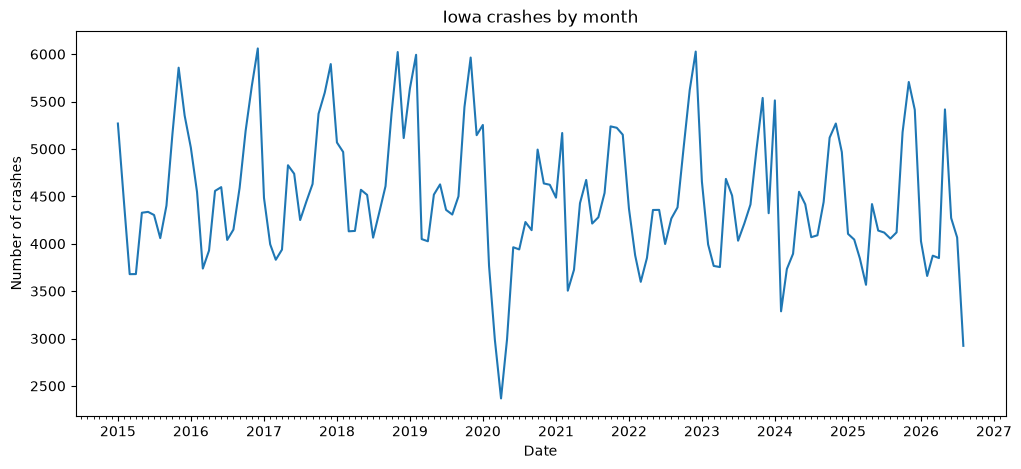

In [26]:
fig, ax = plt.subplots(figsize=(12,5))


ax.plot(monthly_crashes.index, monthly_crashes.values)

ax.set_title("Iowa crashes by month")
ax.set_xlabel("Date")
ax.set_ylabel("Number of crashes")

ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.xaxis.set_minor_locator(mdates.MonthLocator())


plt.show()

In [25]:
print(type(monthly_crashes.index))
print(monthly_crashes.index.min())
print(monthly_crashes.index.max())

<class 'pandas.DatetimeIndex'>
2015-01-01 00:00:00
2026-08-01 00:00:00
